# 1D s-wave Superconducting Mean-Field SCF

This notebook shows the spin-singlet s-wave attractive-Hubbard SCF path. The normal Hamiltonian is spinful, the BdG Hamiltonian is rebuilt at each iteration from the current onsite pairing and Hartree profiles, and the new fields are obtained from the local normal and anomalous densities.


In [1]:
using LinearAlgebra
using Plots
using ITensors
using ITensorMPS

include("../src/TensorBinding.jl")
using .TensorBinding

## 1. Spinful normal chain

Onsite s-wave pairing needs spin. We therefore start from a spinless tight-binding chain and add a spin degree of freedom before entering the superconducting SCF loop.

In [2]:
L = 3
N = 2^L
t = 1.0
mu = 0.0

H_seed = TensorBinding.get_Hamiltonian("chain_1d", t; L=L, scale=4.0)
pos_sites = H_seed.sites

H0 = deepcopy(H_seed)
TensorBinding.add_spin!(H0)

println(H0)


TBHamiltonian | L=3, N=8 +spin, scale=auto, maxlinkdim=3 | geometry: 8 sites, 1D | no Tn cache


## 2. Initial pairing seed

A uniform positive seed is enough for this minimal s-wave example. For spatially varying seeds, pass a function or an MPS as `initial_delta`.

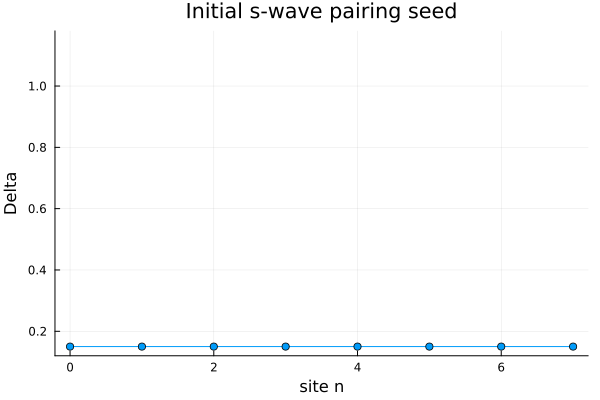

In [3]:
Delta0 = 0.15
Delta0_mps = TensorBinding.scf_profile_mps(
    L,
    pos_sites,
    n -> Delta0;
    type=ComplexF64,
    tol=1e-10,
)

Delta0_vals = [TensorBinding.scf_eval_profile_mps(Delta0_mps, n) for n in 0:N-1]

plot(0:N-1, real.(Delta0_vals);
     marker=:circle,
     xlabel="site n",
     ylabel="Delta",
     title="Initial s-wave pairing seed",
     legend=false)


## 3. Pairing + Hartree SCF

The attractive-Hubbard wrapper uses positive `U` as attraction: `Delta_new = -U * F_singlet`, `V_up = -U * (rho_down - background)`, and `V_down = -U * (rho_up - background)`.


In [4]:
U = 3

result = TensorBinding.scf_swave_hubbard(
    H0,
    U;
    initial_delta=Delta0_mps,
    background=0.5,
    mu=mu,
    density_method=:mcweeny,
    scale=4.8,
    max_scf_iter=35,
    purif_maxiter=30,
    purif_tol=1e-5,
    scf_tol=1e-3,
    mix=0.8,
    maxdim=90,
    cutoff=1e-8,
    verbose=true,
)

println("converged = ", result.converged)
println("iterations = ", result.iterations)
println("final RMS = ", result.rms_error)


┌ Warning: Calling `inner(x::MPS, A::MPO, y::MPS)` where the site indices of the `MPS`
│ `x` and the `MPS` resulting from contracting `MPO` `A` with `MPS` `y` don't
│ match is deprecated as of ITensors v0.3 and will result in an error in ITensors
│ v0.4. The most common cause of this is something like the following:
│ 
│ ```julia
│ s = siteinds("S=1/2")
│ psi = random_mps(s)
│ H = MPO(s, "Id")
│ inner(psi, H, psi)
│ ```
│ 
│ `psi` has the Index structure `-s-(psi)` and `H` has the Index structure
│ `-s'-(H)-s-`, so the Index structure of would be `(dag(psi)-s- -s'-(H)-s-(psi)`
│  unless the prime levels were fixed. Previously we tried fixing the prime level
│   in situations like this, but we will no longer be doing that going forward.
│ 
│ There are a few ways to fix this. You can simply change:
│ 
│ ```julia
│ inner(psi, H, psi)
│ ```
│ 
│ to:
│ 
│ ```julia
│ inner(psi', H, psi)
│ ```
│ 
│ in which case the Index structure will be `(dag(psi)-s'-(H)-s-(psi)`.
│ 
│ Alternatively, you c

s-wave SCF iter=1 rms=0.07880480203245635
s-wave SCF iter=2 rms=0.1074501491776762
s-wave SCF iter=3 rms=0.11663195228618509
s-wave SCF iter=4 rms=0.1025248689591587
s-wave SCF iter=5 rms=0.07796374590176662
s-wave SCF iter=6 rms=0.053652827085191535
s-wave SCF iter=7 rms=0.034464185028072386
s-wave SCF iter=8 rms=0.02127128751839609
s-wave SCF iter=9 rms=0.01272318707069909
s-wave SCF iter=10 rms=0.007491989207255191
s-wave SCF iter=11 rms=0.004426016322873069
s-wave SCF iter=12 rms=0.002570287892609021
s-wave SCF iter=13 rms=0.0015639886617721034
s-wave SCF iter=14 rms=0.0008476606812921895
converged = true
iterations = 14
final RMS = 0.0008476606812921895


## 4. Pairing, density, and convergence


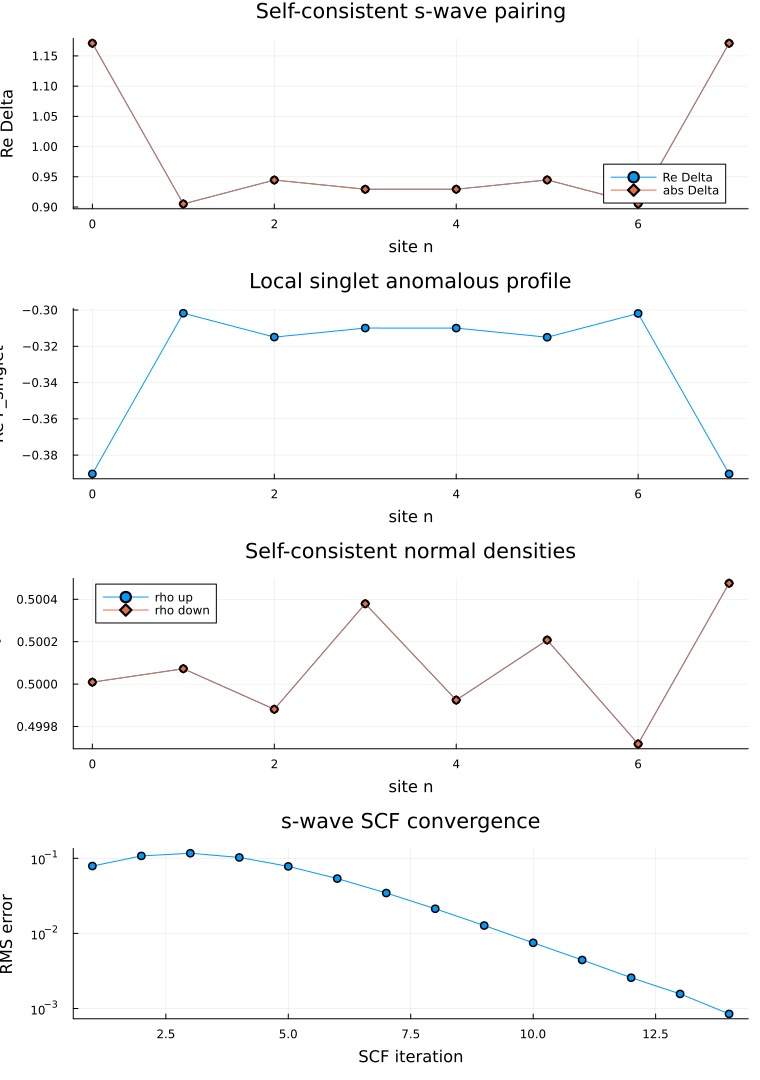

In [5]:
Delta = [TensorBinding.scf_eval_profile_mps(result.delta_mps, n) for n in 0:N-1]
F = [TensorBinding.scf_eval_profile_mps(result.anomalous_mps, n) for n in 0:N-1]
rho_up = [TensorBinding.scf_eval_profile_mps(result.rho_up_mps, n) for n in 0:N-1]
rho_dn = [TensorBinding.scf_eval_profile_mps(result.rho_dn_mps, n) for n in 0:N-1]
hist_iter = [h.iter for h in result.history]
hist_rms = [h.rms_error for h in result.history]

p1 = plot(0:N-1, real.(Delta);
          marker=:circle,
          xlabel="site n",
          ylabel="Re Delta",
          title="Self-consistent s-wave pairing",
          label="Re Delta")
plot!(p1, 0:N-1, abs.(Delta); marker=:diamond, label="abs Delta")

p2 = plot(0:N-1, real.(F);
          marker=:circle,
          xlabel="site n",
          ylabel="Re F_singlet",
          title="Local singlet anomalous profile",
          legend=false)

p3 = plot(0:N-1, real.(rho_up);
          marker=:circle,
          xlabel="site n",
          ylabel="density",
          title="Self-consistent normal densities",
          label="rho up")
plot!(p3, 0:N-1, real.(rho_dn); marker=:diamond, label="rho down")

p4 = plot(hist_iter, hist_rms;
          yscale=:log10,
          marker=:circle,
          xlabel="SCF iteration",
          ylabel="RMS error",
          title="s-wave SCF convergence",
          legend=false)

plot(p1, p2, p3, p4; layout=(4, 1), size=(760, 1080))
